In [1]:
names = open('names.txt', 'r').read()
names

'emma\nolivia\nava\nisabella\nsophia\ncharlotte\nmia\namelia\nharper\nevelyn\nabigail\nemily\nelizabeth\nmila\nella\navery\nsofia\ncamila\naria\nscarlett\nvictoria\nmadison\nluna\ngrace\nchloe\npenelope\nlayla\nriley\nzoey\nnora\nlily\neleanor\nhannah\nlillian\naddison\naubrey\nellie\nstella\nnatalie\nzoe\nleah\nhazel\nviolet\naurora\nsavannah\naudrey\nbrooklyn\nbella\nclaire\nskylar\nlucy\npaisley\neverly\nanna\ncaroline\nnova\ngenesis\nemilia\nkennedy\nsamantha\nmaya\nwillow\nkinsley\nnaomi\naaliyah\nelena\nsarah\nariana\nallison\ngabriella\nalice\nmadelyn\ncora\nruby\neva\nserenity\nautumn\nadeline\nhailey\ngianna\nvalentina\nisla\neliana\nquinn\nnevaeh\nivy\nsadie\npiper\nlydia\nalexa\njosephine\nemery\njulia\ndelilah\narianna\nvivian\nkaylee\nsophie\nbrielle\nmadeline\npeyton\nrylee\nclara\nhadley\nmelanie\nmackenzie\nreagan\nadalynn\nliliana\naubree\njade\nkatherine\nisabelle\nnatalia\nraelynn\nmaria\nathena\nximena\narya\nleilani\ntaylor\nfaith\nrose\nkylie\nalexandra\nmary\nmar

In [2]:
words = names.splitlines()
words[:15]

['emma',
 'olivia',
 'ava',
 'isabella',
 'sophia',
 'charlotte',
 'mia',
 'amelia',
 'harper',
 'evelyn',
 'abigail',
 'emily',
 'elizabeth',
 'mila',
 'ella']

In [3]:
dict = {}
for word in words:
    ch = ["<S>"] + list(word) + ["<E>"]
    for c1, c2 in zip(ch, ch[1:]):
        bigram = (c1, c2)
        dict[bigram] = dict.get(bigram, 0) + 1

In [4]:
sorted(dict.items(), key = lambda k:k[1], reverse = True)

[(('n', '<E>'), 6763),
 (('a', '<E>'), 6640),
 (('a', 'n'), 5438),
 (('<S>', 'a'), 4410),
 (('e', '<E>'), 3983),
 (('a', 'r'), 3264),
 (('e', 'l'), 3248),
 (('r', 'i'), 3033),
 (('n', 'a'), 2977),
 (('<S>', 'k'), 2963),
 (('l', 'e'), 2921),
 (('e', 'n'), 2675),
 (('l', 'a'), 2623),
 (('m', 'a'), 2590),
 (('<S>', 'm'), 2538),
 (('a', 'l'), 2528),
 (('i', '<E>'), 2489),
 (('l', 'i'), 2480),
 (('i', 'a'), 2445),
 (('<S>', 'j'), 2422),
 (('o', 'n'), 2411),
 (('h', '<E>'), 2409),
 (('r', 'a'), 2356),
 (('a', 'h'), 2332),
 (('h', 'a'), 2244),
 (('y', 'a'), 2143),
 (('i', 'n'), 2126),
 (('<S>', 's'), 2055),
 (('a', 'y'), 2050),
 (('y', '<E>'), 2007),
 (('e', 'r'), 1958),
 (('n', 'n'), 1906),
 (('y', 'n'), 1826),
 (('k', 'a'), 1731),
 (('n', 'i'), 1725),
 (('r', 'e'), 1697),
 (('<S>', 'd'), 1690),
 (('i', 'e'), 1653),
 (('a', 'i'), 1650),
 (('<S>', 'r'), 1639),
 (('a', 'm'), 1634),
 (('l', 'y'), 1588),
 (('<S>', 'l'), 1572),
 (('<S>', 'c'), 1542),
 (('<S>', 'e'), 1531),
 (('j', 'a'), 1473),
 (

In [5]:
import torch

In [6]:
chars = sorted(list(set(''.join(words))))
stoi = {j:i + 1 for i,j in enumerate(chars)}
stoi["."] = 0
itos = {j:i for i,j in stoi.items()}
itos

{1: 'a',
 2: 'b',
 3: 'c',
 4: 'd',
 5: 'e',
 6: 'f',
 7: 'g',
 8: 'h',
 9: 'i',
 10: 'j',
 11: 'k',
 12: 'l',
 13: 'm',
 14: 'n',
 15: 'o',
 16: 'p',
 17: 'q',
 18: 'r',
 19: 's',
 20: 't',
 21: 'u',
 22: 'v',
 23: 'w',
 24: 'x',
 25: 'y',
 26: 'z',
 0: '.'}

In [7]:
N = torch.zeros((27, 27), dtype = torch.int32)

In [8]:
for word in words:
    ch = ["."] + list(word) + ["."]
    for c1, c2 in zip(ch, ch[1:]):
        i = stoi[c1]
        j = stoi[c2]
        N[i][j] += 1

In [9]:
import matplotlib.pyplot as plt
%matplotlib inline

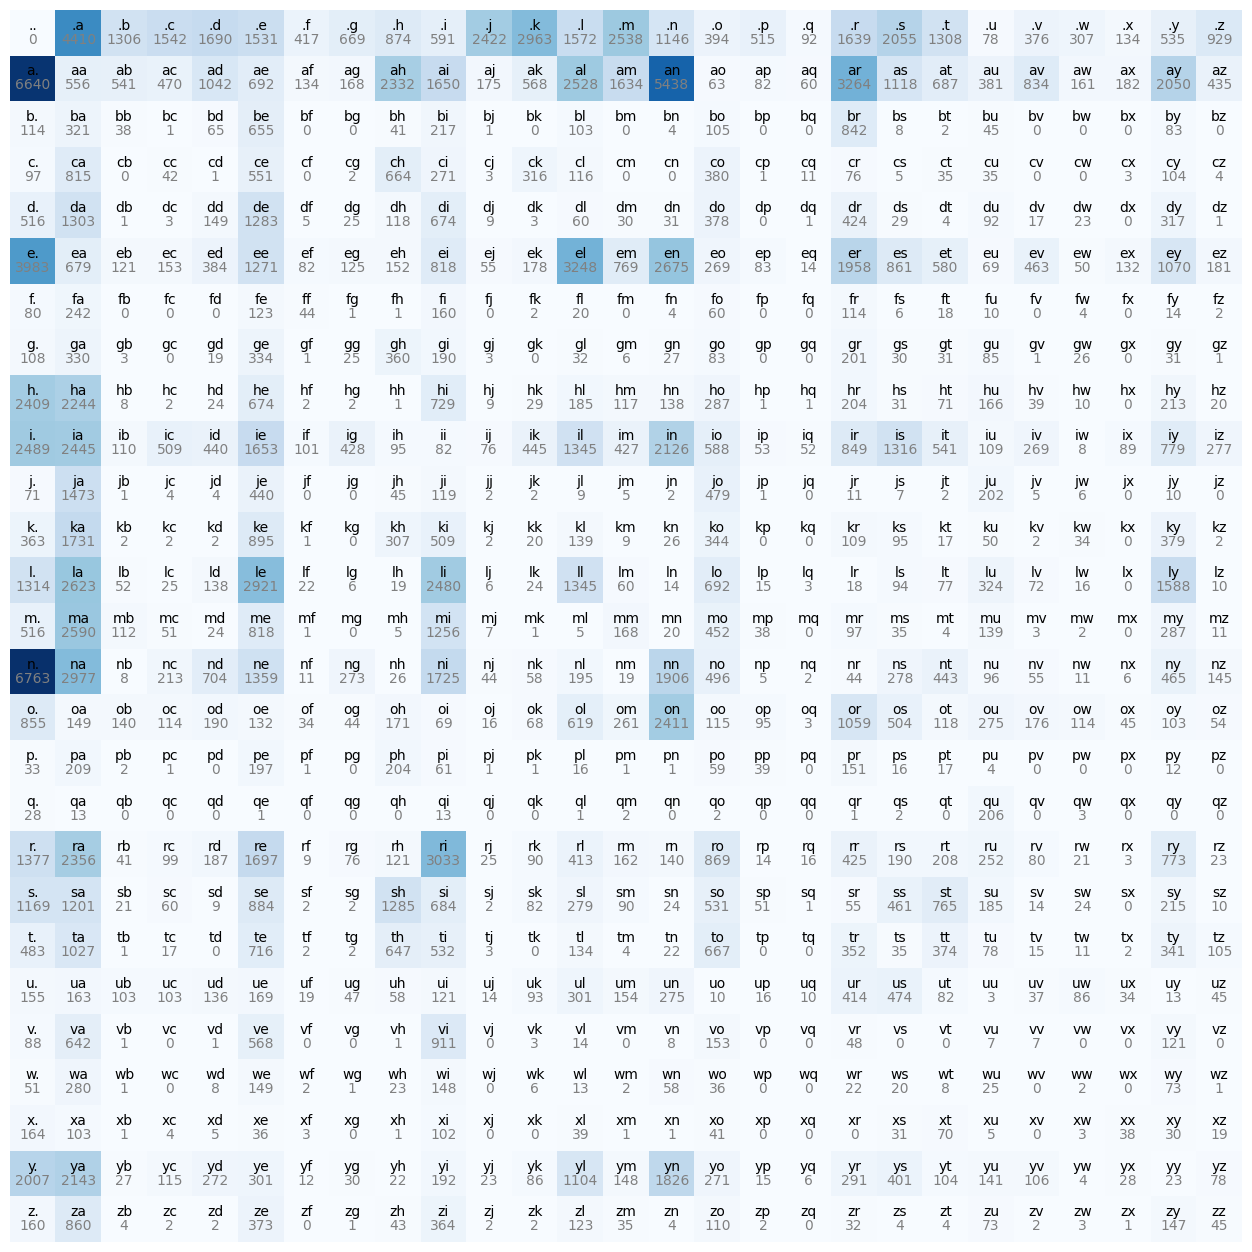

In [10]:
import matplotlib.pyplot as plt
%matplotlib inline

plt.figure(figsize=(16,16))
plt.imshow(N, cmap='Blues')
for i in range(27):
    for j in range(27):
        chstr = itos[i] + itos[j]
        plt.text(j, i, chstr, ha="center", va="bottom", color='black')
        plt.text(j, i, N[i, j].item(), ha="center", va="top", color='gray')
plt.axis('off');

In [11]:
N[0]

tensor([   0, 4410, 1306, 1542, 1690, 1531,  417,  669,  874,  591, 2422, 2963,
        1572, 2538, 1146,  394,  515,   92, 1639, 2055, 1308,   78,  376,  307,
         134,  535,  929], dtype=torch.int32)

In [12]:
p = N[0].float()
p = p / p.sum()
p

tensor([0.0000, 0.1377, 0.0408, 0.0481, 0.0528, 0.0478, 0.0130, 0.0209, 0.0273,
        0.0184, 0.0756, 0.0925, 0.0491, 0.0792, 0.0358, 0.0123, 0.0161, 0.0029,
        0.0512, 0.0642, 0.0408, 0.0024, 0.0117, 0.0096, 0.0042, 0.0167, 0.0290])

In [13]:
g = torch.Generator().manual_seed(2147483647)
ix = torch.multinomial(p, num_samples=1, replacement=True,generator=g)
ix

tensor([13])

In [14]:
g = torch.Generator().manual_seed(2147483647)
p = torch.rand(3, generator=g)
p = p / p.sum()
print(p)
torch.multinomial(p, num_samples=100, replacement=True,generator=g)

tensor([0.6064, 0.3033, 0.0903])


tensor([1, 1, 2, 0, 0, 2, 1, 1, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 0, 2, 0, 0,
        1, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 0, 1, 1,
        0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0,
        0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 2, 0, 0, 0, 0, 0, 0, 1, 0, 0, 2, 0, 1, 0,
        0, 1, 1, 1])

In [69]:
P = (N + 1).float()
P /= P.sum(1, keepdim=True)

In [70]:
g = torch.Generator().manual_seed(2147483647)

for i in range(30):

    ix = 0
    name = []

    while True:
        p = P[ix]
        ix = torch.multinomial(p, num_samples=1, replacement=True,generator=g).item()
        if ix == 0:
            break
        name.append(itos[ix])

    print(''.join(name))


mor
axx
minaymoryles
kondlaisah
anchshizarie
odaren
iaddash
h
jhinatien
egushl
h
br
a
jayn
ilemannariaenien
be
f
akiinela
trttanakeroruceyaaxatona
lamoynayrkiedengin
torrederahnn
ellovyllobrqura
ay
h
kn
jaieendenelele
kianu
eryly
zeeieil
kayvirgjusinn


In [71]:
log_likelihood = 0
n = 0

for word in ["andrejq"]:
    ch = ["."] + list(word) + ["."]
    for c1, c2 in zip(ch, ch[1:]):
        bigram = c1+c2
        prob = P[stoi[c1], stoi[c2]]
        logprob = torch.log(prob)
        log_likelihood += logprob
        n += 1
        # print(f"{bigram} {prob:.4f} {logprob:.4f}")

print("Log likelihood: ", log_likelihood.item())
neg_log_likelihood = -log_likelihood
print("Negative log likelihood: ", neg_log_likelihood.item())
normalized_likelihood = neg_log_likelihood / n
print("Normalized likelihood: ", normalized_likelihood.item())


Log likelihood:  -27.867216110229492
Negative log likelihood:  27.867216110229492
Normalized likelihood:  3.4834020137786865


In [86]:
xs = []
ys = []

for word in words[:1]:
    ch = ["."] + list(word) + ["."]
    for c1, c2 in zip(ch, ch[1:]):
        i = stoi[c1]
        j = stoi[c2]
        xs.append(i)
        ys.append(j)

xs = torch.tensor(xs)
ys = torch.tensor(ys)
print(xs)
print(ys)

tensor([ 0,  5, 13, 13,  1])
tensor([ 5, 13, 13,  1,  0])


In [90]:
import torch.nn.functional as F

xenc = F.one_hot(xs, num_classes = 27).float()
xenc

tensor([[1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0.]])

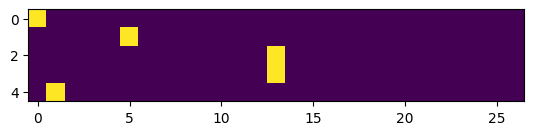

In [92]:
plt.imshow(xenc)

In [96]:
w = torch.randn((27,27))
w

tensor([[-9.8802e-01,  1.2702e+00, -7.3910e-01,  1.1187e+00, -1.3853e+00,
          3.9618e-01, -2.7083e-01, -3.5452e-01,  3.7979e-01,  4.0336e-01,
          2.8067e+00,  3.4039e-01,  4.9409e-02,  9.6334e-01,  2.7870e-01,
         -2.0719e-01,  1.4440e+00,  1.7069e+00,  3.8707e-01, -9.0548e-01,
         -4.9937e-01,  1.2270e+00,  1.0896e+00,  9.3085e-01, -1.3614e+00,
          2.3948e+00,  5.0617e-01],
        [-2.9303e-01, -1.3129e+00,  5.0465e-01, -3.4898e-01, -5.1918e-01,
          1.5817e+00,  4.1611e-01, -4.4228e-03, -1.7663e+00, -1.3020e+00,
         -6.8546e-02, -1.1668e-01,  7.0084e-01, -1.3984e+00, -1.0740e+00,
         -1.6661e+00,  7.3100e-01,  1.1432e+00,  1.7545e-01,  6.1390e-01,
          4.5502e-01, -1.2651e+00,  1.1210e+00, -3.2444e-01,  6.0703e-01,
         -7.2008e-01, -5.9918e-02],
        [ 1.3290e+00, -1.2355e-02, -2.3749e+00,  1.6775e+00,  6.0721e-01,
         -6.0349e-02, -2.2172e+00, -3.6003e-01, -9.0698e-01,  2.1683e+00,
         -2.2127e+00, -1.2671e+00,  3.83

In [99]:
logits = xenc @ w
counts = logits.exp()
probs = counts / counts.sum(1, keepdims = True)
probs

tensor([[0.0052, 0.0499, 0.0067, 0.0429, 0.0035, 0.0208, 0.0107, 0.0098, 0.0205,
         0.0210, 0.2318, 0.0197, 0.0147, 0.0367, 0.0185, 0.0114, 0.0593, 0.0772,
         0.0206, 0.0057, 0.0085, 0.0478, 0.0416, 0.0355, 0.0036, 0.1535, 0.0232],
        [0.0053, 0.0044, 0.0180, 0.0828, 0.0121, 0.0295, 0.0160, 0.0428, 0.0179,
         0.0085, 0.0329, 0.0173, 0.0049, 0.0323, 0.0015, 0.0072, 0.0123, 0.0080,
         0.0189, 0.0096, 0.0097, 0.0119, 0.0728, 0.0142, 0.3022, 0.1045, 0.1026],
        [0.0155, 0.0788, 0.0082, 0.0075, 0.1778, 0.0234, 0.0646, 0.0175, 0.0344,
         0.0081, 0.0090, 0.0865, 0.0131, 0.0081, 0.0111, 0.0338, 0.0185, 0.0445,
         0.0046, 0.0430, 0.0648, 0.0220, 0.0200, 0.0547, 0.0793, 0.0135, 0.0376],
        [0.0155, 0.0788, 0.0082, 0.0075, 0.1778, 0.0234, 0.0646, 0.0175, 0.0344,
         0.0081, 0.0090, 0.0865, 0.0131, 0.0081, 0.0111, 0.0338, 0.0185, 0.0445,
         0.0046, 0.0430, 0.0648, 0.0220, 0.0200, 0.0547, 0.0793, 0.0135, 0.0376],
        [0.0222, 0.0080,

In [103]:
print(probs[0].sum())
print(probs[0].shape)

tensor(1.0000)
torch.Size([27])


In [106]:
## Summary

import torch.nn.functional as F

xs = []
ys = []

for word in words[:1]:
    ch = ["."] + list(word) + ["."]
    for c1, c2 in zip(ch, ch[1:]):
        i = stoi[c1]
        j = stoi[c2]
        xs.append(i)
        ys.append(j)

xs = torch.tensor(xs)
ys = torch.tensor(ys)


xenc = F.one_hot(xs, num_classes = 27).float()

g = torch.Generator().manual_seed(2147483647)
w = torch.randn((27, 27), generator = g)

logits = xenc @ w
counts = logits.exp()
probs = counts / counts.sum(1, keepdims = True)
probs

tensor([[0.0607, 0.0100, 0.0123, 0.0042, 0.0168, 0.0123, 0.0027, 0.0232, 0.0137,
         0.0313, 0.0079, 0.0278, 0.0091, 0.0082, 0.0500, 0.2378, 0.0603, 0.0025,
         0.0249, 0.0055, 0.0339, 0.0109, 0.0029, 0.0198, 0.0118, 0.1537, 0.1459],
        [0.0290, 0.0796, 0.0248, 0.0521, 0.1989, 0.0289, 0.0094, 0.0335, 0.0097,
         0.0301, 0.0702, 0.0228, 0.0115, 0.0181, 0.0108, 0.0315, 0.0291, 0.0045,
         0.0916, 0.0215, 0.0486, 0.0300, 0.0501, 0.0027, 0.0118, 0.0022, 0.0472],
        [0.0312, 0.0737, 0.0484, 0.0333, 0.0674, 0.0200, 0.0263, 0.0249, 0.1226,
         0.0164, 0.0075, 0.0789, 0.0131, 0.0267, 0.0147, 0.0112, 0.0585, 0.0121,
         0.0650, 0.0058, 0.0208, 0.0078, 0.0133, 0.0203, 0.1204, 0.0469, 0.0126],
        [0.0312, 0.0737, 0.0484, 0.0333, 0.0674, 0.0200, 0.0263, 0.0249, 0.1226,
         0.0164, 0.0075, 0.0789, 0.0131, 0.0267, 0.0147, 0.0112, 0.0585, 0.0121,
         0.0650, 0.0058, 0.0208, 0.0078, 0.0133, 0.0203, 0.1204, 0.0469, 0.0126],
        [0.0150, 0.0086,

In [107]:
nlls = torch.zeros(5)
for i in range(5):
  x = xs[i].item()
  y = ys[i].item()
  print('--------')
  print(f'bigram example {i+1}: {itos[x]}{itos[y]} (indexes {x},{y})')
  print('input to the neural net:', x)
  print('output probabilities from the neural net:', probs[i])
  print('label (actual next character):', y)
  p = probs[i, y]
  print('probability assigned by the net to the the correct character:', p.item())
  logp = torch.log(p)
  print('log likelihood:', logp.item())
  nll = -logp
  print('negative log likelihood:', nll.item())
  nlls[i] = nll

print('=========')
print('average negative log likelihood, i.e. loss =', nlls.mean().item())

--------
bigram example 1: .e (indexes 0,5)
input to the neural net: 0
output probabilities from the neural net: tensor([0.0607, 0.0100, 0.0123, 0.0042, 0.0168, 0.0123, 0.0027, 0.0232, 0.0137,
        0.0313, 0.0079, 0.0278, 0.0091, 0.0082, 0.0500, 0.2378, 0.0603, 0.0025,
        0.0249, 0.0055, 0.0339, 0.0109, 0.0029, 0.0198, 0.0118, 0.1537, 0.1459])
label (actual next character): 5
probability assigned by the net to the the correct character: 0.01228625513613224
log likelihood: -4.399273872375488
negative log likelihood: 4.399273872375488
--------
bigram example 2: em (indexes 5,13)
input to the neural net: 5
output probabilities from the neural net: tensor([0.0290, 0.0796, 0.0248, 0.0521, 0.1989, 0.0289, 0.0094, 0.0335, 0.0097,
        0.0301, 0.0702, 0.0228, 0.0115, 0.0181, 0.0108, 0.0315, 0.0291, 0.0045,
        0.0916, 0.0215, 0.0486, 0.0300, 0.0501, 0.0027, 0.0118, 0.0022, 0.0472])
label (actual next character): 13
probability assigned by the net to the the correct character: 0.

### OPTIMIZATION

In [130]:
import torch.nn.functional as F

xs = []
ys = []

for word in words:
    ch = ["."] + list(word) + ["."]
    for c1, c2 in zip(ch, ch[1:]):
        i = stoi[c1]
        j = stoi[c2]
        xs.append(i)
        ys.append(j)

xs = torch.tensor(xs)
ys = torch.tensor(ys)
num = xs.nelement()


xenc = F.one_hot(xs, num_classes = 27).float()

g = torch.Generator().manual_seed(2147483647)
w = torch.randn((27, 27), generator = g, requires_grad = True)

In [131]:
## Gradient descent

for i in range(100):

    # forward pass
    logits = xenc @ w
    counts = logits.exp()
    probs = counts / counts.sum(1, keepdims = True)
    loss = -probs[torch.arange(num), ys].log().mean() + 0.01 * (w**2).mean()
    print(f"loss: {loss.item()}")

    # backward
    w.grad = None
    loss.backward()

    # update
    w.data -= 50 * w.grad

loss: 3.7686190605163574
loss: 3.3788068294525146
loss: 3.161090850830078
loss: 3.027186155319214
loss: 2.9344842433929443
loss: 2.8672313690185547
loss: 2.816654682159424
loss: 2.777146577835083
loss: 2.745253801345825
loss: 2.7188303470611572
loss: 2.696505546569824
loss: 2.6773719787597656
loss: 2.6608052253723145
loss: 2.6463515758514404
loss: 2.633665084838867
loss: 2.622471570968628
loss: 2.6125476360321045
loss: 2.6037068367004395
loss: 2.595794916152954
loss: 2.5886809825897217
loss: 2.582256317138672
loss: 2.5764293670654297
loss: 2.5711238384246826
loss: 2.5662729740142822
loss: 2.5618226528167725
loss: 2.5577263832092285
loss: 2.5539441108703613
loss: 2.550442695617676
loss: 2.5471925735473633
loss: 2.5441696643829346
loss: 2.5413522720336914
loss: 2.538722038269043
loss: 2.536262035369873
loss: 2.5339581966400146
loss: 2.531797409057617
loss: 2.5297679901123047
loss: 2.527860164642334
loss: 2.5260636806488037
loss: 2.5243709087371826
loss: 2.522773265838623
loss: 2.52126383

In [132]:
g = torch.Generator().manual_seed(2147483647)

for i in range(30):

    ix = 0
    name = []

    while True:
        xenc = F.one_hot(torch.tensor([ix]), num_classes=27).float()
        logits = xenc @ w
        counts = logits.exp()
        p = counts / counts.sum(1, keepdims = True)

        ix = torch.multinomial(p, num_samples=1, replacement=True,generator=g).item()
        if ix == 0:
            break
        name.append(itos[ix])

    print(''.join(name))


mor
axx
minaymoryles
kondmaisah
anchthizarie
odaren
iaddash
h
jionatien
egwver
ga
t
a
jayn
ilemannariaenien
ad
f
akiinela
trttanakerorudayaaxetona
lamoyonuuriedengin
torrederahnn
ellovwiqucoskh
a
wai
kole
hahemenelgha
kianv
eryly
zeeieil
kayxtrglynenn
